

## Phase 1: ECG Signal Processing 

## 1. Import Libraries

In [ ]:
! pip install wfdb numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import wfdb
print("WFDB installed successfully")


WFDB installed successfully


In [1]:
# ========================
# STEP 1: IMPORT LIBRARIES
# ========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

## 2. Load MIT-BIH ECG Dataset

In [2]:
# ========================
# STEP 2: LOAD DATASET
# ========================

record = wfdb.rdrecord('mit-bih-arrhythmia-database-1.0.0/100')
signal = record.p_signal

print(signal.shape)

(650000, 2)


### ECG Visualization

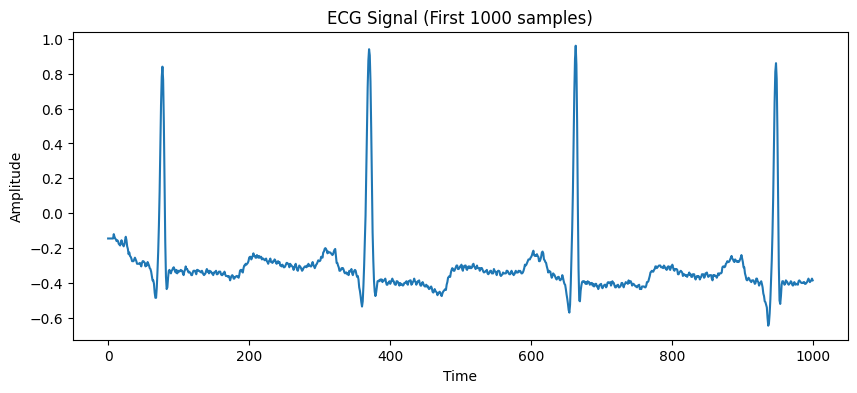

In [12]:
import matplotlib.pyplot as plt

# first channel plot
plt.figure(figsize=(10,4))
plt.plot(signal[:1000, 0])  # first 1000 samples, channel 1
plt.title("ECG Signal (First 1000 samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

## Annotation load

In [13]:
annotation = wfdb.rdann('mit-bih-arrhythmia-database-1.0.0/100', 'atr')

print(annotation.symbol[:20])
print(annotation.sample[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


##  Class distribution check

In [14]:
from collections import Counter

counts = Counter(annotation.symbol)
print(counts)

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


## 3. EDA

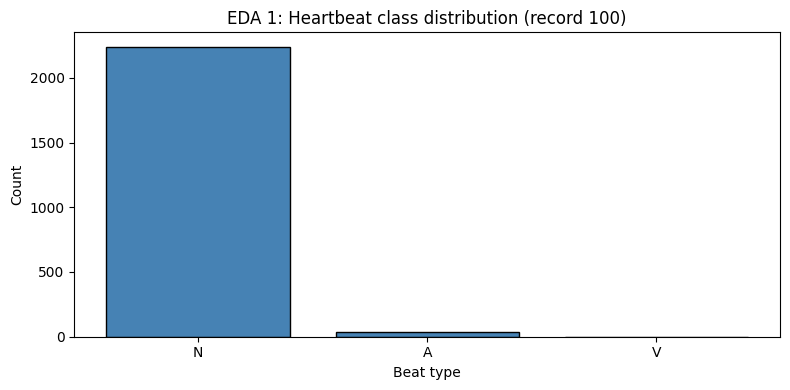

Class counts: Counter({'N': 2239, 'A': 33, 'V': 1})

── EDA 2: Signal statistics per class ──
  N: mean=-0.2998  std=0.2367  min=-0.8750  max=1.4350  count=2237
  A: mean=-0.2883  std=0.2387  min=-0.6850  max=1.3550  count=33
  V: mean=-0.2851  std=0.7661  min=-2.7150  max=0.9400  count=1


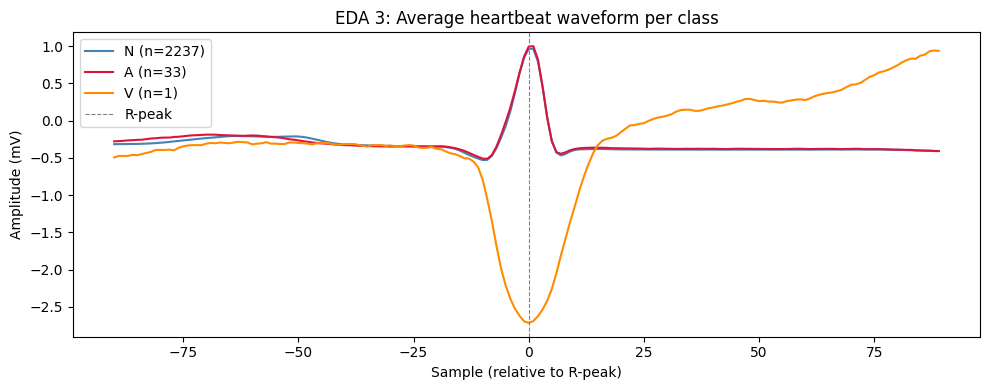

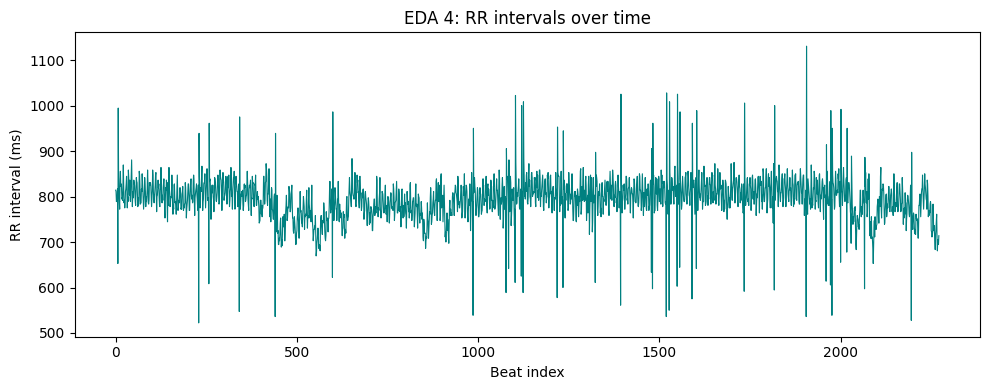


── EDA 4: RR stats ──
  Mean RR : 794.6 ms
  Std RR  : 48.8 ms
  Min RR  : 522.2 ms
  Max RR  : 1130.6 ms


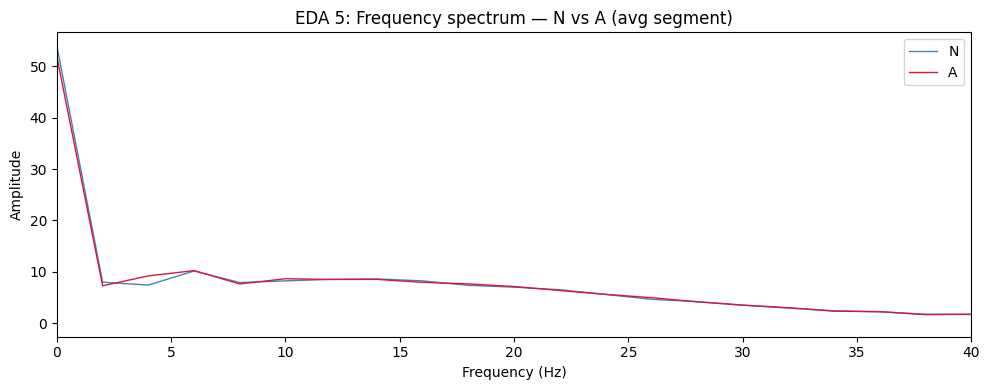

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.fft import fft, fftfreq

record = wfdb.rdrecord('mit-bih-arrhythmia-database-1.0.0/100')
annotation = wfdb.rdann('mit-bih-arrhythmia-database-1.0.0/100', 'atr')

signal = record.p_signal[:, 0]          # channel 0 (MLII lead)
symbols = annotation.symbol
samples = annotation.sample

valid = {'N', 'A', 'V', 'L', 'R', 'B', 'a', 'J', 'S', 'e', 'j', 'n', 'E', '/'}
filtered = [(s, sym) for s, sym in zip(samples, symbols) if sym in valid]
filt_samples, filt_symbols = zip(*filtered)

# ────────────────────────────────────────────────────────────────
# EDA 1 — Class distribution bar chart
# ────────────────────────────────────────────────────────────────
counts = Counter(filt_symbols)
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
plt.title('EDA 1: Heartbeat class distribution (record 100)')
plt.xlabel('Beat type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda1_class_dist.png', dpi=150)
plt.show()
print("Class counts:", counts)

# ────────────────────────────────────────────────────────────────
# EDA 2 — Signal statistics per class
# ────────────────────────────────────────────────────────────────
window = 90          # ±90 samples around R-peak → 180-sample segment
segments = {}

for samp, sym in zip(filt_samples, filt_symbols):
    start, end = samp - window, samp + window
    if start >= 0 and end < len(signal):
        segments.setdefault(sym, []).append(signal[start:end])

print("\n── EDA 2: Signal statistics per class ──")
for cls, segs in segments.items():
    arr = np.array(segs)
    print(f"  {cls}: mean={arr.mean():.4f}  std={arr.std():.4f}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}  count={len(segs)}")

# ────────────────────────────────────────────────────────────────
# EDA 3 — Average waveform per class
# ────────────────────────────────────────────────────────────────
plot_classes = [c for c in ['N', 'A', 'V'] if c in segments]
colors       = ['steelblue', 'crimson', 'darkorange']
x_axis       = np.arange(-window, window)

plt.figure(figsize=(10, 4))
for cls, col in zip(plot_classes, colors):
    mean_wave = np.mean(segments[cls], axis=0)
    plt.plot(x_axis, mean_wave, label=f'{cls} (n={len(segments[cls])})', color=col)

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='R-peak')
plt.title('EDA 3: Average heartbeat waveform per class')
plt.xlabel('Sample (relative to R-peak)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.tight_layout()
plt.savefig('eda3_avg_waveform.png', dpi=150)
plt.show()

# ────────────────────────────────────────────────────────────────
# 4 — RR interval analysis
# ────────────────────────────────────────────────────────────────
fs = record.fs                           # 360 Hz for MIT-BIH
rr_intervals = np.diff(filt_samples) / fs * 1000   # milliseconds

plt.figure(figsize=(10, 4))
plt.plot(rr_intervals, color='teal', linewidth=0.8)
plt.title('EDA 4: RR intervals over time')
plt.xlabel('Beat index')
plt.ylabel('RR interval (ms)')
plt.tight_layout()
plt.savefig('eda4_rr_intervals.png', dpi=150)
plt.show()

print(f"\n── EDA 4: RR stats ──")
print(f"  Mean RR : {rr_intervals.mean():.1f} ms")
print(f"  Std RR  : {rr_intervals.std():.1f} ms")
print(f"  Min RR  : {rr_intervals.min():.1f} ms")
print(f"  Max RR  : {rr_intervals.max():.1f} ms")

# ────────────────────────────────────────────────────────────────
# 5 — Frequency domain (FFT) for N vs A
# ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
for cls, col in zip(['N', 'A'], ['steelblue', 'crimson']):
    if cls not in segments:
        continue
    mean_seg = np.mean(segments[cls], axis=0)
    N_pts    = len(mean_seg)
    freqs    = fftfreq(N_pts, d=1/fs)
    power    = np.abs(fft(mean_seg))
    pos_mask = freqs >= 0
    plt.plot(freqs[pos_mask], power[pos_mask],
             label=f'{cls}', color=col, linewidth=1)

plt.title('EDA 5: Frequency spectrum — N vs A (avg segment)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 40)
plt.legend()
plt.tight_layout()
plt.savefig('eda5_fft.png', dpi=150)
plt.show()

In [17]:
! pip install imbalanced-learn

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.23.5

   ---------------------------------------- 0/3 [numpy]
    Uninstalling numpy-1.23.5:
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
      Successfully uninstalled numpy-1.23.5
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ----------------------------------------

  You can safely remove it manually.


In [22]:
! pip install numpy==1.26.4

In [23]:
pip install --upgrade scipy scikit-learn imbalanced-learn

In [25]:

pip uninstall numpy scipy scikit-learn imbalanced-learn -y

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Found existing installation: imbalanced-learn 0.14.1
Uninstalling imbalanced-learn-0.14.1:
  Successfully uninstalled imbalanced-learn-0.14.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


In [27]:
! pip install numpy==1.24.3 scipy==1.10.1 scikit-learn==1.3.0 imbalanced-learn==0.11.0

   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ------------------------------- -------- 11.5/14.8 MB 55.5 MB/s eta 0:00:01
   ---------------------------------------  14.7/14.8 MB 54.2 MB/s eta 0:00:01
   ---------------------------------------- 14.8/14.8 MB 30.1 MB/s  0:00:00
   ---------------------------------------- 0.0/42.5 MB ? eta -:--:--
   ------------ --------------------------- 12.8/42.5 MB 62.0 MB/s eta 0:00:01
   ------------------------ --------------- 26.0/42.5 MB 63.3 MB/s eta 0:00:01
   ---------------------------------- ----- 37.0/42.5 MB 60.3 MB/s eta 0:00:01
   ---------------------------------------  42.5/42.5 MB 57.5 MB/s eta 0:00:01
   ---------------------------------------  42.5/42.5 MB 57.5 MB/s eta 0:00:01
   ---------------------------------------- 42.5/42.5 MB 35.6 MB/s  0:00:01
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------  9.2/9.2 MB 47.4 MB/s eta 0:00:01
   ------

In [1]:

import numpy as np
import scipy
import sklearn
import imblearn

print("numpy    :", np.__version__)      # 1.24.3
print("scipy    :", scipy.__version__)   # 1.10.1
print("sklearn  :", sklearn.__version__) # 1.3.0
print("imblearn :", imblearn.__version__)# 0.11.0

numpy    : 1.24.3
scipy    : 1.10.1
sklearn  : 1.3.0
imblearn : 0.11.0


## 4.  Preprocessing and Data Preparation (MIT-BIH Dataset)

Loading all 48 records...

Total segments: 109468  |  Skipped: 26

Class distribution (raw, before anything):
  N: 90608
  S: 2781
  V: 7235
  F: 802
  Q: 8042

Train size: 87574  |  Test size: 21894

Applying SMOTE on training data only...


d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "d:\ecg_env\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\ecg_env\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ecg_env\lib\subprocess.py", line 1456, in _execute_child
   


Training class distribution AFTER SMOTE:
  N: 72486
  S: 72486
  V: 72486
  F: 72486
  Q: 72486

Test class distribution (unchanged — real world):
  N: 18122
  S: 556
  V: 1447
  F: 160
  Q: 1609

Saved: X_train, y_train, X_test, y_test
  X_train shape: (362430, 180)
  X_test shape : (21894, 180)


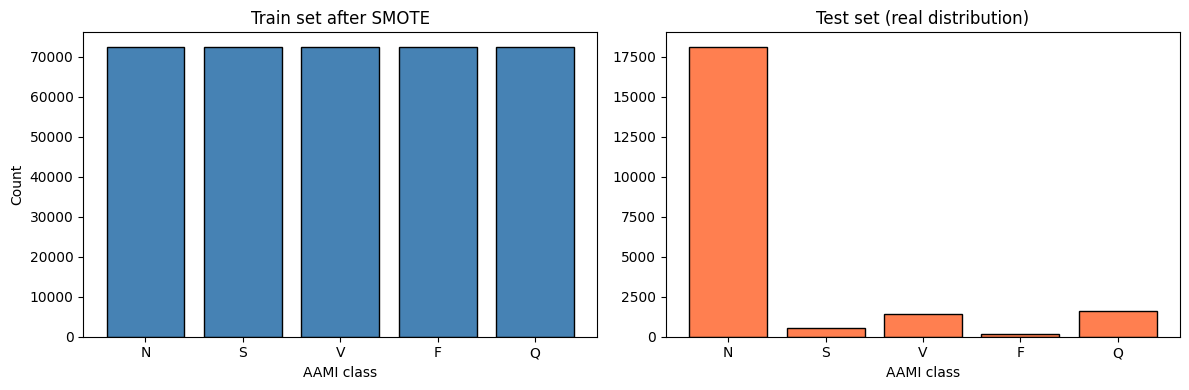

In [2]:
import wfdb
import numpy as np
from collections import Counter
from scipy.signal import butter, filtfilt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

DB_PATH = 'mit-bih-arrhythmia-database-1.0.0'

AAMI_MAP = {
    'N':'N', 'L':'N', 'R':'N', 'e':'N', 'j':'N',
    'A':'S', 'a':'S', 'J':'S', 'S':'S',
    'V':'V', 'E':'V',
    'F':'F',
    '/':'Q', 'f':'Q', 'Q':'Q'
}

def butter_bandpass(signal, fs=360, lowcut=0.5, highcut=40, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

WINDOW = 90
all_segments = []
all_labels   = []
skipped      = 0

print("Loading all 48 records...")

for rec_id in ALL_RECORDS:
    path = f'{DB_PATH}/{rec_id}'
    try:
        record     = wfdb.rdrecord(path)
        annotation = wfdb.rdann(path, 'atr')
        signal     = butter_bandpass(record.p_signal[:, 0], fs=record.fs)

        for samp, sym in zip(annotation.sample, annotation.symbol):
            if sym not in AAMI_MAP:
                continue
            start, end = samp - WINDOW, samp + WINDOW
            if start < 0 or end >= len(signal):
                skipped += 1
                continue
            seg = signal[start:end]
            seg = (seg - seg.mean()) / (seg.std() + 1e-8)
            all_segments.append(seg)
            all_labels.append(AAMI_MAP[sym])

    except Exception as ex:
        print(f"  Record {rec_id} failed: {ex}")

X = np.array(all_segments)
label_map = {'N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4}
y = np.array([label_map[l] for l in all_labels])

print(f"\nTotal segments: {len(X)}  |  Skipped: {skipped}")
print("\nClass distribution (raw, before anything):")
for cls, idx in label_map.items():
    print(f"  {cls}: {(y == idx).sum()}")

# ────────────────────────────────────────────────────────────────
# STEP 1: Split FIRST — don't touch test data 
# ────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")

# ────────────────────────────────────────────────────────────────
# STEP 2: SMOTE only on train  — test kept like real world
# ────────────────────────────────────────────────────────────────
print("\nApplying SMOTE on training data only...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTraining class distribution AFTER SMOTE:")
rev_map = {v: k for k, v in label_map.items()}
for idx in sorted(label_map.values()):
    print(f"  {rev_map[idx]}: {(y_train_res == idx).sum()}")

print("\nTest class distribution (unchanged — real world):")
for idx in sorted(label_map.values()):
    print(f"  {rev_map[idx]}: {(y_test == idx).sum()}")

# ────────────────────────────────────────────────────────────────
# STEP 3: Save — 4 files
# ────────────────────────────────────────────────────────────────
np.save('X_train.npy', X_train_res)
np.save('y_train.npy', y_train_res)
np.save('X_test.npy',  X_test)
np.save('y_test.npy',  y_test)

print("\nSaved: X_train, y_train, X_test, y_test")
print(f"  X_train shape: {X_train_res.shape}")
print(f"  X_test shape : {X_test.shape}")

# ────────────────────────────────────────────────────────────────
# STEP 4: Comparison plot
# ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
classes = [rev_map[i] for i in sorted(label_map.values())]

train_counts = [(y_train_res == i).sum() for i in sorted(label_map.values())]
test_counts  = [(y_test == i).sum()      for i in sorted(label_map.values())]

axes[0].bar(classes, train_counts, color='steelblue', edgecolor='black')
axes[0].set_title('Train set after SMOTE')
axes[0].set_xlabel('AAMI class')
axes[0].set_ylabel('Count')

axes[1].bar(classes, test_counts, color='coral', edgecolor='black')
axes[1].set_title('Test set (real distribution)')
axes[1].set_xlabel('AAMI class')

plt.tight_layout()
plt.savefig('train_test_distribution.png', dpi=150)
plt.show()

In [7]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Mon May  4 15:56:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.97                 Driver Version: 580.97         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1080 Ti   WDDM  |   00000000:AF:00.0  On |                  N/A |
| 28%   50C    P8             17W /  250W |    6676MiB /  11264MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Step 1: CPU PyTorch uninstall 
! pip uninstall torch torchvision torchaudio -y 

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


You can safely remove it manually.


In [ ]:
# Step 2: CUDA 12.8  install 
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 10.5 MB/s eta 0:04:23
   ---------------------------------------- 0.0/2.8 GB 28.7 MB/s eta 0:01:36
   ---------------------------------------- 0.0/2.8 GB 25.4 MB/s eta 0:01:48
   ---------------------------------------- 0.0/2.8 GB 38.4 MB/s eta 0:01:11
    --------------------------------------- 0.0/2.8 GB 50.9 MB/s eta 0:00:54
    --------------------------------------- 0.1/2.8 GB 53.9 MB/s eta 0:00:50
   - -------------------------------------- 0.1/2.8 GB 56.8 MB/s eta 0:00:48
   - -------------------------------------- 0.1/2.8 GB 62.9 MB/s eta 0:00:43
   - -------------------------------------- 0.1/2.8 GB 64.7 MB/s eta 0:00:41
   - -------------------------------------- 0.1/2.8 GB 67.0 MB/s eta 0:00:40
   -- ------------------------------------- 0.2/2.8 GB 70.7 MB/s eta 0:00:37
   -- -------------------

In [8]:
# cu128 uninstall 
! pip uninstall torch torchvision torchaudio -y

# cu118 install  —  for GTX 1080 Ti best compatible
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 16.8 MB/s eta 0:02:48
   ---------------------------------------- 0.0/2.8 GB 33.5 MB/s eta 0:01:24
   ---------------------------------------- 0.0/2.8 GB 54.3 MB/s eta 0:00:52
    --------------------------------------- 0.0/2.8 GB 61.0 MB/s eta 0:00:46
    --------------------------------------- 0.1/2.8 GB 66.8 MB/s eta 0:00:42
   - -------------------------------------- 0.1/2.8 GB 70.1 MB/s eta 0:00:40
   - -------------------------------------- 0.1/2.8 GB 71.5 MB/s eta 0:00:39
   - -------------------------------------- 0.1/2.8 GB 69.9 MB/s eta 0:00:39
   - -------------------------------------- 0.1/2.8 GB 65.0 MB/s eta 0:00:42
   - -------------------------------------- 0.1/2.8 GB 70.5 MB/s eta 0:00:39
   -- ------------------------------------- 0.2/2.8 GB 70.1 MB/s eta 0:00:39
   -- -------------------

In [9]:
import torch
print("PyTorch     :", torch.__version__)
print("CUDA avail  :", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU 0       :", torch.cuda.get_device_name(0))

# Quick GPU test
x = torch.randn(3, 3).cuda()
print("GPU tensor test passed:", x.shape)

PyTorch     : 2.11.0+cu128
CUDA avail  : True
CUDA version: 12.8
GPU 0       : NVIDIA GeForce GTX 1080 Ti
GPU tensor test passed: torch.Size([3, 3])


## Model Building and Training

Train : 317,126
Val   : 45,304
Test  : 21,894

GPU 0 VRAM used: 0.00 GB
GPU 1 VRAM used: 0.00 GB

Training on 2x GTX 1080 Ti...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
--------------------------------------------------------------------
    1 |     0.8118 |    0.8023 |   0.6155 |  0.8951 |   0.001000
    2 |     0.6415 |    0.8984 |   0.5417 |  0.9298 |   0.001000
    3 |     0.6048 |    0.9185 |   0.5293 |  0.9399 |   0.001000
    4 |     0.5850 |    0.9292 |   0.5020 |  0.9548 |   0.001000
    5 |     0.5729 |    0.9352 |   0.5034 |  0.9521 |   0.001000
    6 |     0.5639 |    0.9398 |   0.4913 |  0.9623 |   0.001000
    7 |     0.5555 |    0.9436 |   0.4858 |  0.9649 |   0.001000
    8 |     0.5499 |    0.9465 |   0.4785 |  0.9652 |   0.001000
    9 |     0.5452 |    0.9490 |   0.4761 |  0.9679 |   0.001000
   10 |     0.5420 |    0.9503 |   0.4776 |  0.9696 |   0.001000
   11 |     0.5379 |    0.9519 |   0.4674 |  0.9724 |   0.001000
   12 |     0.5349 |  

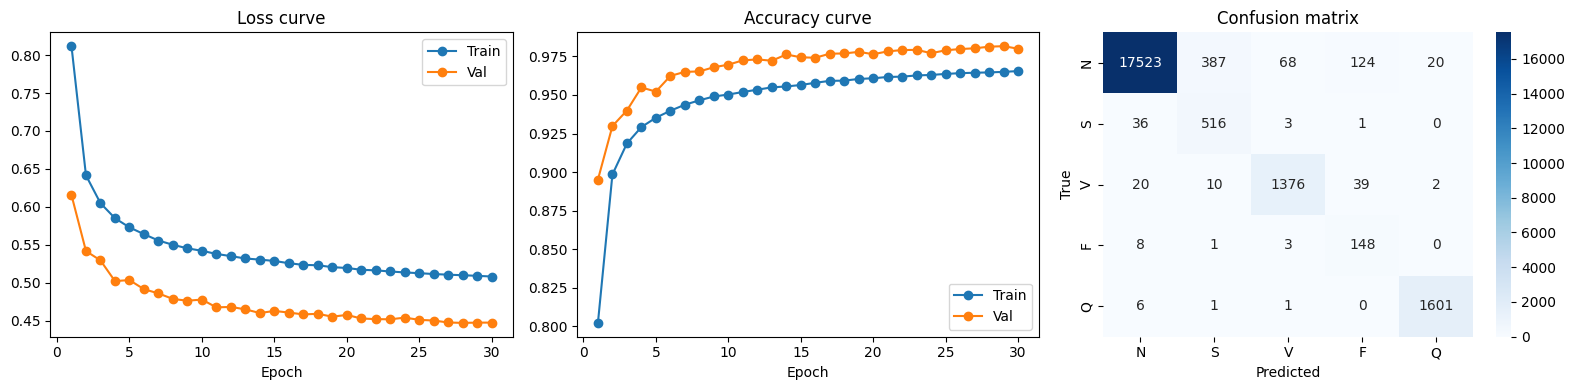


GPU 0 peak VRAM: 0.13 GB
GPU 1 peak VRAM: 0.13 GB


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────
# Step 1: Data load + split
# ────────────────────────────────────────────────────────────────
X_train_full = np.load('X_train.npy')
y_train_full = np.load('y_train.npy')
X_test       = np.load('X_test.npy')
y_test       = np.load('y_test.npy')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.125,
    random_state=42,
    stratify=y_train_full
)

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

def to_loader(X, y, batch_size=512, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size,
                      shuffle=shuffle,
                      pin_memory=True,
                      num_workers=0)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

# ────────────────────────────────────────────────────────────────
# Step 2: CNN model
# ────────────────────────────────────────────────────────────────
class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.AdaptiveAvgPool1d(1),         # hardcoded size fix
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ────────────────────────────────────────────────────────────────
# Step 3: Device setup — dono GPU
# ────────────────────────────────────────────────────────────────
device = torch.device('cuda')

model = ECG_CNN(num_classes=5)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

print(f"\nGPU 0 VRAM used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"GPU 1 VRAM used: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# FIX: verbose=True removed — newer PyTorch mein supported nahi
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

# ────────────────────────────────────────────────────────────────
# Step 4: Train + val loop with early stopping
# ────────────────────────────────────────────────────────────────
EPOCHS   = 30
PATIENCE = 5

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
prev_lr       = optimizer.param_groups[0]['lr']

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(yb)

    return total_loss / total, correct / total

print("\nTraining on 2x GTX 1080 Ti...\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10}")
print("-" * 68)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    scheduler.step(vl_loss)

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # LR change manually print karo
    lr_tag = ''
    if current_lr != prev_lr:
        lr_tag = '  ← LR reduced'
        prev_lr = current_lr

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
          f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {current_lr:>10.6f}{lr_tag}")

    # Early stopping
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.cpu().clone()
                         for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch} "
                  f"(no val loss improvement for {PATIENCE} epochs)")
            break

# Best model restore + save
model.load_state_dict(best_weights)
torch.save(best_weights, 'ecg_cnn_best.pth')
print("\nBest model saved: ecg_cnn_best.pth")

# ────────────────────────────────────────────────────────────────
# Step 5: Test evaluation
# ────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

label_names = ['N', 'S', 'V', 'F', 'Q']
print("\n── Test Classification Report ──")
print(classification_report(all_true, all_preds,
                             target_names=label_names, digits=4))

# ────────────────────────────────────────────────────────────────
# Step 6: Plots
# ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('Accuracy curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=label_names, yticklabels=label_names,
            cmap='Blues')
axes[2].set_title('Confusion matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('cnn_results_gpu.png', dpi=150)
plt.show()

# GPU memory final
print(f"\nGPU 0 peak VRAM: {torch.cuda.max_memory_allocated(0)/1e9:.2f} GB")
print(f"GPU 1 peak VRAM: {torch.cuda.max_memory_allocated(1)/1e9:.2f} GB")

## ResNet-style 1D CNN Model

Train : 317,126
Val   : 45,304
Test  : 21,894

Total parameters : 4,194,309
GPU 0 VRAM used  : 0.04 GB

Training ECG ResNet on 2x GTX 1080 Ti...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
--------------------------------------------------------------------
    1 |     0.5393 |    0.9398 |   0.4321 |  0.9814 |   0.001000
    2 |     0.4450 |    0.9843 |   0.4168 |  0.9898 |   0.001000
    3 |     0.4306 |    0.9889 |   0.4055 |  0.9934 |   0.001000
    4 |     0.4219 |    0.9913 |   0.4087 |  0.9919 |   0.001000
    5 |     0.4162 |    0.9924 |   0.4051 |  0.9931 |   0.001000
    6 |     0.4135 |    0.9933 |   0.3996 |  0.9960 |   0.001000
    7 |     0.4105 |    0.9944 |   0.3988 |  0.9964 |   0.001000
    8 |     0.4090 |    0.9951 |   0.3974 |  0.9968 |   0.001000
    9 |     0.4071 |    0.9958 |   0.3992 |  0.9962 |   0.001000
   10 |     0.4065 |    0.9959 |   0.3985 |  0.9966 |   0.001000
   11 |     0.4056 |    0.9962 |   0.3963 |  0.9976 |   0.001000
   12

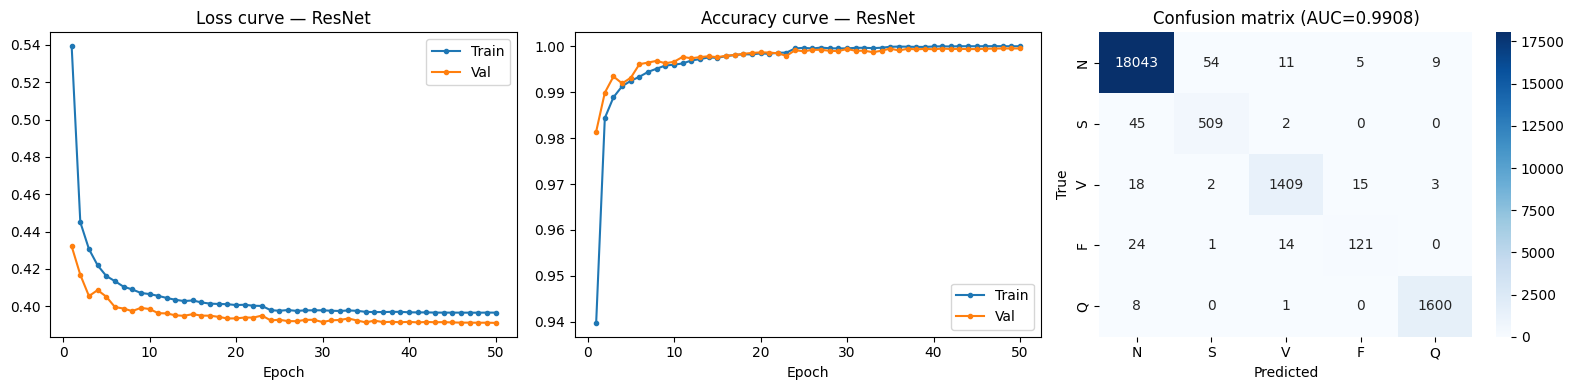


GPU 0 peak VRAM : 0.40 GB
GPU 1 peak VRAM : 0.36 GB


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────
# Step 1: Data load + split
# ────────────────────────────────────────────────────────────────
X_train_full = np.load('X_train.npy')
y_train_full = np.load('y_train.npy')
X_test       = np.load('X_test.npy')
y_test       = np.load('y_test.npy')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.125,
    random_state=42,
    stratify=y_train_full
)

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

def to_loader(X, y, batch_size=512, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size,
                      shuffle=shuffle,
                      pin_memory=True,
                      num_workers=0)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

# ────────────────────────────────────────────────────────────────
# Step 2: Residual Block
# ────────────────────────────────────────────────────────────────
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=7, stride=1):
        super().__init__()
        padding = kernel_size // 2

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels,
                      kernel_size, stride=stride, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_channels, out_channels,
                      kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(out_channels),
        )

        # Skip connection — channels match karne ke liye
        self.skip = nn.Sequential(
            nn.Conv1d(in_channels, out_channels,
                      kernel_size=1, stride=stride),
            nn.BatchNorm1d(out_channels),
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv_block(x) + self.skip(x))

# ────────────────────────────────────────────────────────────────
# Step 3: Full ResNet ECG Model
# ────────────────────────────────────────────────────────────────
class ECG_ResNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # Entry block
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),          # 180 → 90
        )

        # Residual blocks — increasing channels
        self.layer1 = nn.Sequential(
            ResidualBlock1D(64,  64,  kernel_size=7),
            ResidualBlock1D(64,  64,  kernel_size=7),
        )

        self.layer2 = nn.Sequential(
            ResidualBlock1D(64,  128, kernel_size=5, stride=2),  # 90 → 45
            ResidualBlock1D(128, 128, kernel_size=5),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock1D(128, 256, kernel_size=3, stride=2),  # 45 → 23
            ResidualBlock1D(256, 256, kernel_size=3),
        )

        self.layer4 = nn.Sequential(
            ResidualBlock1D(256, 512, kernel_size=3, stride=2),  # 23 → 12
            ResidualBlock1D(512, 512, kernel_size=3),
        )

        # Global pooling + classifier
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        return self.classifier(x)

# ────────────────────────────────────────────────────────────────
# Step 4: Device + model setup
# ────────────────────────────────────────────────────────────────
device = torch.device('cuda')

model = ECG_ResNet(num_classes=5)
model = nn.DataParallel(model)
model = model.to(device)

# Model size check
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters : {total_params:,}")
print(f"GPU 0 VRAM used  : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# ────────────────────────────────────────────────────────────────
# Step 5: Train + val loop
# ────────────────────────────────────────────────────────────────
EPOCHS   = 50
PATIENCE = 7

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
prev_lr       = optimizer.param_groups[0]['lr']

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(yb)

    return total_loss / total, correct / total

print("\nTraining ECG ResNet on 2x GTX 1080 Ti...\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10}")
print("-" * 68)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    lr_tag = ''
    if current_lr != prev_lr:
        lr_tag  = '  ← LR reduced'
        prev_lr = current_lr

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
          f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {current_lr:>10.6f}{lr_tag}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.cpu().clone()
                         for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model.load_state_dict(best_weights)
torch.save(best_weights, 'ecg_resnet_best.pth')
print("\nBest model saved: ecg_resnet_best.pth")

# ────────────────────────────────────────────────────────────────
# Step 6: Test evaluation + AUC
# ────────────────────────────────────────────────────────────────
model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out   = model(xb.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_probs = np.array(all_probs)
label_names = ['N', 'S', 'V', 'F', 'Q']

# AUC — one vs rest
auc = roc_auc_score(all_true, all_probs,
                    multi_class='ovr', average='macro')

print("\n── Test Classification Report ──")
print(classification_report(all_true, all_preds,
                             target_names=label_names, digits=4))
print(f"Macro AUC-ROC : {auc:.4f}")

# ────────────────────────────────────────────────────────────────
# Step 7: Plots
# ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o', markersize=3)
axes[0].set_title('Loss curve — ResNet')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o', markersize=3)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='o', markersize=3)
axes[1].set_title('Accuracy curve — ResNet')
axes[1].set_xlabel('Epoch')
axes[1].legend()

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=label_names, yticklabels=label_names,
            cmap='Blues')
axes[2].set_title(f'Confusion matrix (AUC={auc:.4f})')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('resnet_results.png', dpi=150)
plt.show()

print(f"\nGPU 0 peak VRAM : {torch.cuda.max_memory_allocated(0)/1e9:.2f} GB")
print(f"GPU 1 peak VRAM : {torch.cuda.max_memory_allocated(1)/1e9:.2f} GB")

## Evaluation Matrix

       COMPLETE EVALUATION — ECG ResNet

── 1. Classification Report ──
              precision    recall  f1-score   support

           N     0.9948    0.9956    0.9952     18122
           S     0.8993    0.9155    0.9073       556
           V     0.9805    0.9737    0.9771      1447
           F     0.8582    0.7562    0.8040       160
           Q     0.9926    0.9944    0.9935      1609

    accuracy                         0.9903     21894
   macro avg     0.9451    0.9271    0.9354     21894
weighted avg     0.9902    0.9903    0.9903     21894

── 2. Per-class AUC-ROC ──
  N : 0.9976
  S : 0.9808
  V : 0.9989
  F : 0.9775
  Q : 0.9993

  Macro AUC-ROC : 0.9908

── 3. Per-class Average Precision (PR-AUC) ──
  N : 0.9989
  S : 0.8671
  V : 0.9873
  F : 0.7825
  Q : 0.9969


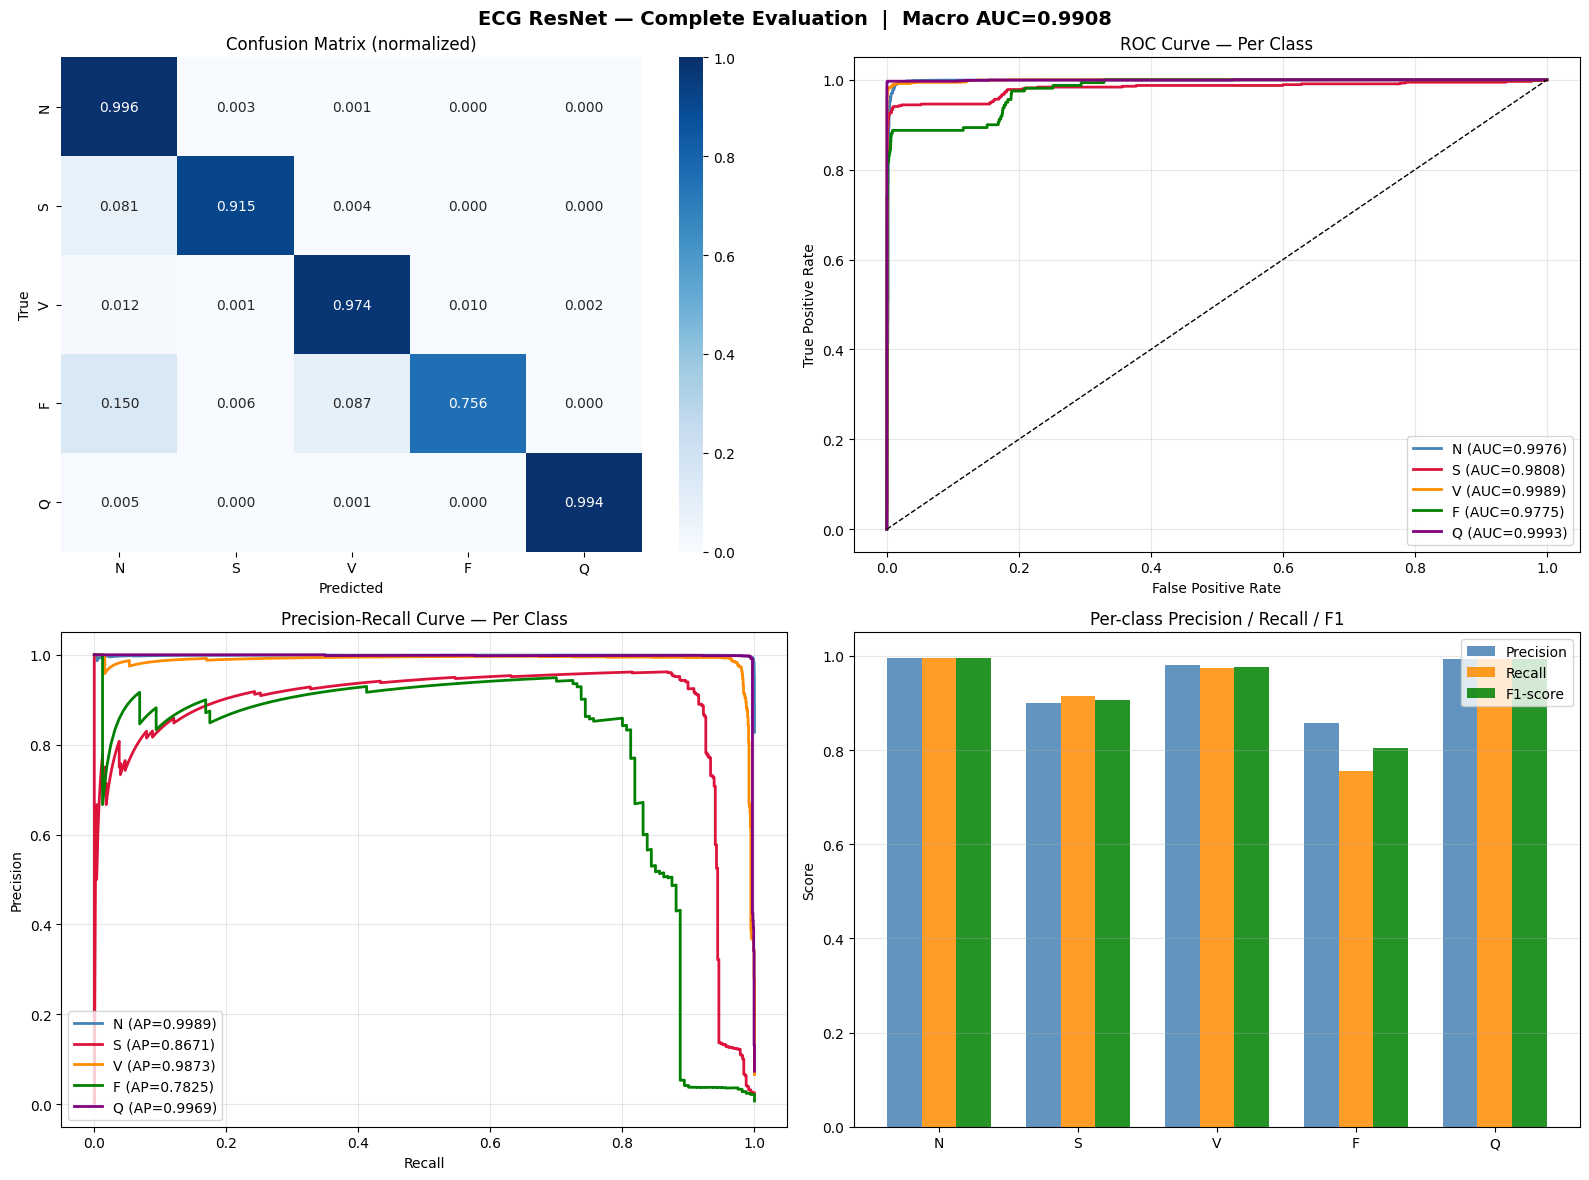


── 4. Summary Table ──
Class   Precision   Recall       F1      AUC   Support
----------------------------------------------------
N          0.9948   0.9956   0.9952   0.9976    18,122
S          0.8993   0.9155   0.9073   0.9808       556
V          0.9805   0.9737   0.9771   0.9989     1,447
F          0.8582   0.7562   0.8040   0.9775       160
Q          0.9926   0.9944   0.9935   0.9993     1,609
----------------------------------------------------
Macro      0.9451   0.9271   0.9354   0.9908


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────
# Load saved model + test data
# ────────────────────────────────────────────────────────────────
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

def to_loader(X, y, batch_size=512, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size, shuffle=shuffle,
                      pin_memory=True, num_workers=0)

test_loader = to_loader(X_test, y_test)

# Model reload
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=7, stride=1):
        super().__init__()
        padding = kernel_size // 2
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels,
                      kernel_size, stride=stride, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_channels, out_channels,
                      kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(out_channels),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_channels, out_channels,
                      kernel_size=1, stride=stride),
            nn.BatchNorm1d(out_channels),
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv_block(x) + self.skip(x))

class ECG_ResNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock1D(64,  64,  kernel_size=7),
            ResidualBlock1D(64,  64,  kernel_size=7),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock1D(64,  128, kernel_size=5, stride=2),
            ResidualBlock1D(128, 128, kernel_size=5),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock1D(128, 256, kernel_size=3, stride=2),
            ResidualBlock1D(256, 256, kernel_size=3),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock1D(256, 512, kernel_size=3, stride=2),
            ResidualBlock1D(512, 512, kernel_size=3),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        return self.classifier(x)

device = torch.device('cuda')
model  = ECG_ResNet(num_classes=5)
model  = nn.DataParallel(model)
model.load_state_dict(torch.load('ecg_resnet_best.pth'))
model  = model.to(device)
model.eval()

# ────────────────────────────────────────────────────────────────
# Predictions
# ────────────────────────────────────────────────────────────────
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out   = model(xb.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

label_names = ['N', 'S', 'V', 'F', 'Q']
n_classes   = 5

# ────────────────────────────────────────────────────────────────
# 1. Classification Report
# ────────────────────────────────────────────────────────────────
print("=" * 60)
print("       COMPLETE EVALUATION — ECG ResNet")
print("=" * 60)
print("\n── 1. Classification Report ──")
print(classification_report(all_true, all_preds,
                             target_names=label_names, digits=4))

# ────────────────────────────────────────────────────────────────
# 2. Per-class AUC
# ────────────────────────────────────────────────────────────────
print("── 2. Per-class AUC-ROC ──")
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(all_true, classes=list(range(n_classes)))

per_class_auc = {}
for i, name in enumerate(label_names):
    a = roc_auc_score(y_bin[:, i], all_probs[:, i])
    per_class_auc[name] = a
    print(f"  {name} : {a:.4f}")

macro_auc = roc_auc_score(all_true, all_probs,
                           multi_class='ovr', average='macro')
print(f"\n  Macro AUC-ROC : {macro_auc:.4f}")

# ────────────────────────────────────────────────────────────────
# 3. Per-class Average Precision (PR-AUC)
# ────────────────────────────────────────────────────────────────
print("\n── 3. Per-class Average Precision (PR-AUC) ──")
for i, name in enumerate(label_names):
    ap = average_precision_score(y_bin[:, i], all_probs[:, i])
    print(f"  {name} : {ap:.4f}")

# ────────────────────────────────────────────────────────────────
# 4. Plots — 4 subplots
# ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Confusion Matrix (normalized)
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.3f', ax=axes[0, 0],
            xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', vmin=0, vmax=1)
axes[0, 0].set_title('Confusion Matrix (normalized)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')

# ── Plot 2: ROC curves per class
colors = ['steelblue', 'crimson', 'darkorange', 'green', 'purple']
for i, (name, col) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    axes[0, 1].plot(fpr, tpr, color=col, linewidth=2,
                    label=f'{name} (AUC={per_class_auc[name]:.4f})')

axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0, 1].set_title('ROC Curve — Per Class')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# ── Plot 3: Precision-Recall curves
for i, (name, col) in enumerate(zip(label_names, colors)):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    ap = average_precision_score(y_bin[:, i], all_probs[:, i])
    axes[1, 0].plot(rec, prec, color=col, linewidth=2,
                    label=f'{name} (AP={ap:.4f})')

axes[1, 0].set_title('Precision-Recall Curve — Per Class')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc='lower left')
axes[1, 0].grid(alpha=0.3)

# ── Plot 4: Per-class metrics bar chart
report = classification_report(all_true, all_preds,
                                target_names=label_names,
                                output_dict=True)
metrics    = ['precision', 'recall', 'f1-score']
x          = np.arange(len(label_names))
width      = 0.25
bar_colors = ['steelblue', 'darkorange', 'green']

for j, (metric, col) in enumerate(zip(metrics, bar_colors)):
    vals = [report[cls][metric] for cls in label_names]
    axes[1, 1].bar(x + j * width, vals, width,
                   label=metric.capitalize(), color=col, alpha=0.85)

axes[1, 1].set_title('Per-class Precision / Recall / F1')
axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels(label_names)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle(f'ECG ResNet — Complete Evaluation  |  Macro AUC={macro_auc:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('complete_evaluation.png', dpi=150)
plt.show()

# ────────────────────────────────────────────────────────────────
# 5. Summary table
# ────────────────────────────────────────────────────────────────
print("\n── 4. Summary Table ──")
print(f"{'Class':<6} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'AUC':>8} {'Support':>9}")
print("-" * 52)
for cls in label_names:
    p  = report[cls]['precision']
    r  = report[cls]['recall']
    f  = report[cls]['f1-score']
    a  = per_class_auc[cls]
    s  = int(report[cls]['support'])
    print(f"{cls:<6} {p:>10.4f} {r:>8.4f} {f:>8.4f} {a:>8.4f} {s:>9,}")
print("-" * 52)
print(f"{'Macro':<6} {report['macro avg']['precision']:>10.4f} "
      f"{report['macro avg']['recall']:>8.4f} "
      f"{report['macro avg']['f1-score']:>8.4f} "
      f"{macro_auc:>8.4f}")